## Importar librerías

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

## Cargando la tabla limpia

In [ ]:
df = pd.read_csv("archive/processed/diabetes_clean.csv")

In [4]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Risk_Group
0,0,1,1,1,40.0,1,0,0,0,0,...,0,5,18.0,15.0,1,0,9,4,3,0
1,0,0,0,0,25.0,1,0,0,1,0,...,1,3,0.0,0.0,0,0,7,6,1,0
2,0,1,1,1,28.0,0,0,0,0,1,...,1,5,30.0,30.0,1,0,9,4,8,0
3,0,1,0,1,27.0,0,0,0,1,1,...,0,2,0.0,0.0,0,0,11,3,6,0
4,0,1,1,1,24.0,0,0,0,1,1,...,0,2,3.0,0.0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229776,0,1,1,1,45.0,0,0,0,0,1,...,0,3,0.0,5.0,0,1,5,6,7,0
229777,2,1,1,1,18.0,0,0,0,0,0,...,0,4,0.0,0.0,1,0,11,2,4,1
229778,0,0,0,1,28.0,0,0,0,1,1,...,0,1,0.0,0.0,0,0,2,5,2,0
229779,0,1,0,1,23.0,0,0,0,0,1,...,0,3,0.0,0.0,0,1,7,5,1,0


### Train test Split

In [6]:
# Creando features y target para mi modelo 
features = df.drop(["Diabetes_012","Risk_Group"], axis=1)
target= df["Risk_Group"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    random_state=42)

### Escalando 

In [8]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns)

### Balanceando variable target

In [9]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

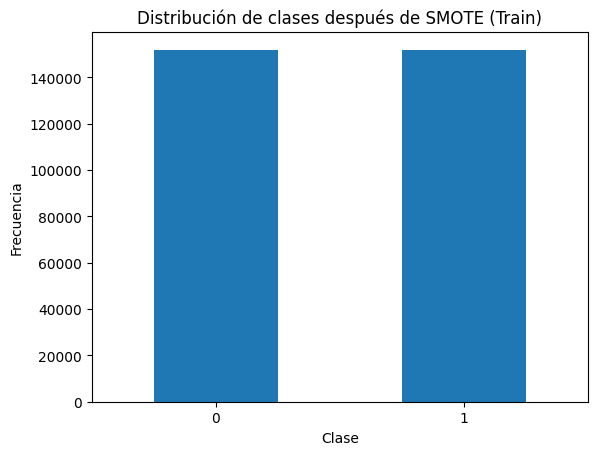

In [10]:
pd.Series(y_train_bal).value_counts().plot(kind="bar")

plt.title("Distribución de clases después de SMOTE (Train)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

In [11]:
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)
    y_pred = knn.predict(X_test)
    print(k, accuracy_score(y_test, y_pred), "Precision", precision_score(y_test, y_pred), "Recall:", recall_score(y_test, y_pred), "F1:", f1_score(y_test, y_pred))

1 0.33751115172879 Precision 0.1712956230914643 Recall: 0.7511796964672873 F1: 0.2789750390754511
2 0.7230454555345214 Precision 0.25780553077609275 Recall: 0.3317178931258768 F1: 0.2901282766313441
3 0.5571077311399787 Precision 0.18659520112207584 Recall: 0.4750669557454406 F1: 0.2679470579772695
4 0.7478077333159258 Precision 0.23750175045511834 Recall: 0.21629894146154827 F1: 0.2264050193565612
5 0.7052462084122114 Precision 0.23721787194841087 Recall: 0.3284019895421502 F1: 0.27545999144201966
6 0.7639967795983201 Precision 0.22815270490320247 Recall: 0.16082132381073844 F1: 0.18865948533812088
7 0.6918423743934548 Precision 0.22840938386182005 Recall: 0.3389873740594312 F1: 0.272923298079885
8 0.7475901386078291 Precision 0.23731656184486374 Recall: 0.21655401096798876 F1: 0.22646038943718325
9 0.724525099549579 Precision 0.2480920020909566 Recall: 0.3026399693916592 F1: 0.2726645984143399
10 0.7332288878734469 Precision 0.24734133790737564 Recall: 0.2758576712154062 F1: 0.260822

In [14]:
knn = KNeighborsClassifier(n_neighbors=13)

In [15]:
scores = cross_val_score(knn, X_train_bal, y_train_bal, cv=5)
scores.mean()

0.7841699983653077

In [16]:
knn.fit(X_train_bal, y_train_bal)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Accuracy es: {accuracy}")
print(f"Precision es: {precision}")
print(f"Recall es: {recall}")
print(f"F1 score es: {f1}")

Accuracy es: 0.7216528494027026
Precision es: 0.2560843432850527
Recall es: 0.3314628236194363
F1 score es: 0.28893829905503055
